<a href="https://colab.research.google.com/github/KeziahAcheampong/Keziah_A/blob/main/week10_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import pandas for data manipulation and loading datasets
import pandas as pd

# Import matplotlib for visualizing results (like confusion matrices)
import matplotlib.pyplot as plt

# Import RandomForestClassifier (a machine learning model)
from sklearn.ensemble import RandomForestClassifier

# Import evaluation tools to measure model performance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
# This section loads the training and testing data from GitHub.
# X_train and X_test contain the predictor variables (features),
# while y_train and y_test contain the outcome variable we want the model to predict.

X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_train.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_test.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_test.csv')

# This converts y_train and y_test from dataframes into 1D series.
# Scikit-learn models usually expect the target variable in this format,
# so this step helps prevent warnings or errors during model training.
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [5]:
# Create a Random Forest model
# random_state ensures reproducibility (same results every time)
rf = RandomForestClassifier(random_state=42)

# Train (fit) the model using training data
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [6]:
# Import additional evaluation metrics
from sklearn.metrics import classification_report, roc_auc_score

# Predict class labels (0 or 1)
y_pred = rf.predict(X_test)

# Predict probabilities (used for AUC and threshold tuning)
y_prob = rf.predict_proba(X_test)[:, 1]

# Print classification metrics (precision, recall, F1-score)
print(classification_report(y_test, y_pred))

# Print ROC-AUC score (how well model separates classes)
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1289
           1       0.29      0.06      0.11       216

    accuracy                           0.84      1505
   macro avg       0.58      0.52      0.51      1505
weighted avg       0.78      0.84      0.80      1505

AUC-ROC: 0.7488


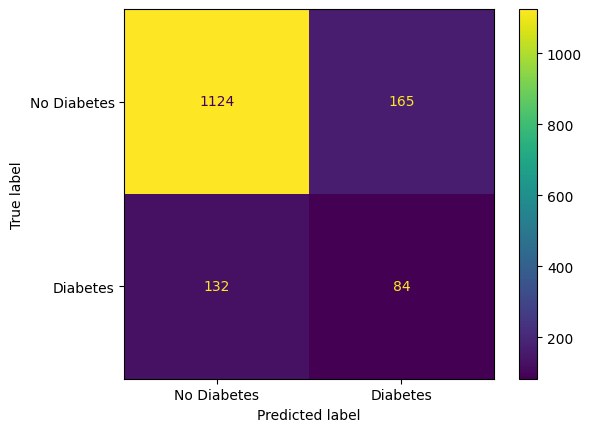

In [7]:
# Change classification threshold to 0.3
# This makes the model more likely to predict "Diabetes"
y_pred_03 = (y_prob >= 0.3).astype(int)

# Display confusion matrix to evaluate performance
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_03, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

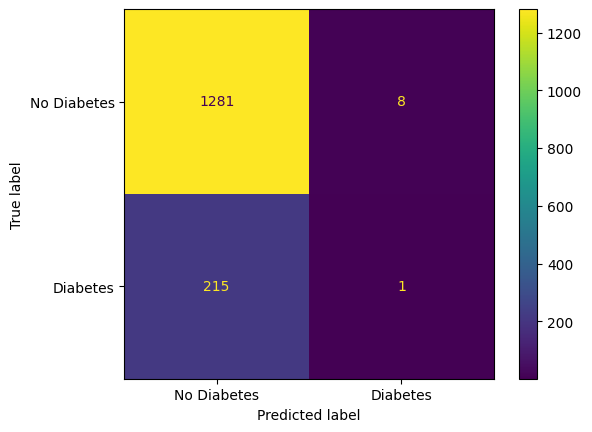

In [8]:
# Change classification threshold to 0.7
# This makes the model more strict about predicting "Diabetes"
y_pred_07 = (y_prob >= 0.7).astype(int)

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_07, display_labels=['No Diabetes', 'Diabetes'])
plt.show()

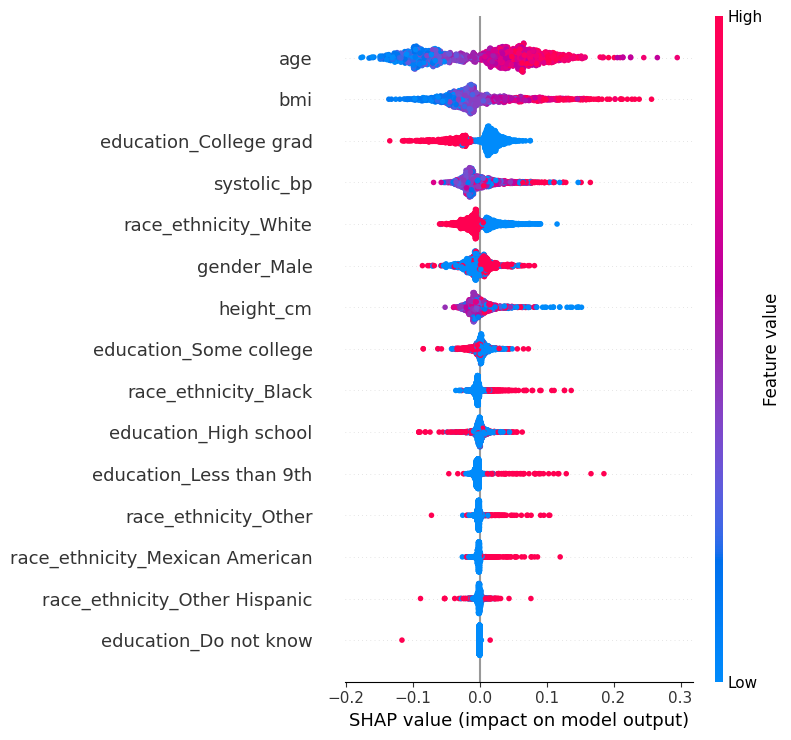

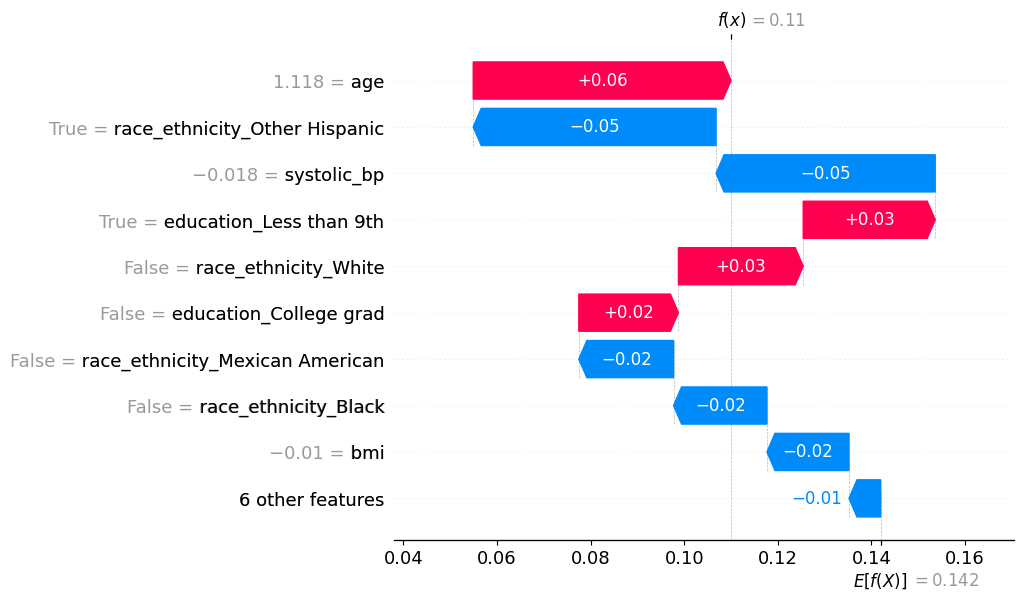

In [9]:
# Import SHAP for model explainability
import shap

# Create SHAP explainer for Random Forest model
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values (impact of each feature on predictions)
shap_values = explainer(X_test)

# Summary plot shows which features are most important overall
shap.summary_plot(shap_values[:, :, 1], X_test)

# Waterfall plot explains one specific prediction
shap.plots.waterfall(shap_values[0, :, 1])

In [10]:
# This notebook evaluates a machine learning model by measuring its performance
# using metrics like accuracy, precision, recall, and AUC.
# It also explores how changing decision thresholds affects predictions
# and uses SHAP to explain how features influence model decisions.